In [ ]:
# Importing Libraries
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,recall_score,precision_score,classification_report,roc_auc_score,roc_curve
from sklearn.model_selection import RandomizedSearchCV
%matplotlib inline
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv("D:\\Trips_and_Travel\\dataset\\Cleaned_data.csv")

In [49]:
# Train test Split
X = df.drop("ProdTaken",axis=1)
y= df["ProdTaken"]

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.20,random_state=42)

In [50]:
#Scaling and Encoding

cat = [col for col in X.columns if X[col].dtype=="O" ]
num = [col for col in X.columns if X[col].dtype!="O" ]

scaler = StandardScaler()
oh_encoder = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoding",oh_encoder,cat),
        ("Scaling",scaler,num)
    ]
)


In [51]:
X_train= preprocessor.fit_transform(X_train)
X_test= preprocessor.transform(X_test)

In [52]:
model = RandomForestClassifier()

model.fit(X_train,y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("=="*50)
#y_train scores
accuracy =  accuracy_score(y_train_pred,y_train)
recall =recall_score(y_train_pred,y_train)
precision = precision_score(y_train_pred,y_train)
classification = classification_report(y_train_pred,y_train)

print("--"*50)
#y_test scores
accuracy =  accuracy_score(y_test_pred,y_test)
recall =recall_score(y_test_pred,y_test)
precision = precision_score(y_test_pred,y_test)
classification = classification_report(y_test_pred,y_test)

----------------------------------------------------------------------------------------------------


In [53]:
Models = {
    "Random Forest Classifier":RandomForestClassifier()
    ,"Decision Tree Classifier": DecisionTreeClassifier()
    ,"Logistic Regression" : LogisticRegression()
    }

for m in range(len(list(Models))):

    model= list(Models.values())[m]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_train_prob = model.predict_proba(X_train)[:,1]
    y_test_prob = model.predict_proba(X_test)[:,1]

    print("=="*50)
    print(f"Model Name  = {list(Models.keys())[m]}")
    #y_train scores
    accuracy_train =  accuracy_score(y_train_pred,y_train)
    recall_train =recall_score(y_train_pred,y_train)
    precision_train = precision_score(y_train_pred,y_train)
    classification_train = classification_report(y_train_pred,y_train)
    Roc_auc_score_train = roc_auc_score(y_train,y_train_prob)

    #print(classification_train)
    print(f"Accuracy Score for Training set is {accuracy_train}")
    print(f"Recall Score for Training set is {recall_train}")
    print(f"Precision Score for Training set is {precision_train}")
    print(f"ROC Score for Training set is {Roc_auc_score_train}")

    print("--"*50)
    #y_test scores
    accuracy_test =  accuracy_score(y_test_pred,y_test)
    recall_test =recall_score(y_test_pred,y_test)
    precision_test = precision_score(y_test_pred,y_test)
    classification_test = classification_report(y_test_pred,y_test)
    Roc_auc_score_test = roc_auc_score(y_test,y_test_prob)

    #print(classification_test)
    print(f"Accuracy Score for Test set is {accuracy_test}")
    print(f"Recall Score for Test set is {recall_test}")
    print(f"Precision Score for Test set is {precision_test}")
    print(f"ROC Score for Test set is {Roc_auc_score_test}")


Model Name  = Random Forest Classifier
Accuracy Score for Training set is 1.0
Recall Score for Training set is 1.0
Precision Score for Training set is 1.0
ROC Score for Training set is 1.0
----------------------------------------------------------------------------------------------------
Accuracy Score for Test set is 0.9151329243353783
Recall Score for Test set is 0.9655172413793104
Precision Score for Test set is 0.5863874345549738
ROC Score for Test set is 0.9697140044040261
Model Name  = Decision Tree Classifier
Accuracy Score for Training set is 1.0
Recall Score for Training set is 1.0
Precision Score for Training set is 1.0
ROC Score for Training set is 1.0
----------------------------------------------------------------------------------------------------
Accuracy Score for Test set is 0.8967280163599182
Recall Score for Test set is 0.75
Precision Score for Test set is 0.7068062827225131
ROC Score for Test set is 0.8248135606751067
Model Name  = Logistic Regression
Accuracy Sco

In [54]:
## Hyperparameter Training
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

# Models list for Hyperparameter tuning
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_params)
                   
                   ]

In [55]:
model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=100,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
---------------- Best Params for RF -------------------
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None}


In [56]:
Models = {
    "Random Forest Classifier":RandomForestClassifier(n_estimators=200,min_samples_split=2,
                                          max_features=5,max_depth=None)
    }

for m in range(len(list(Models))):

    model= list(Models.values())[m]
    model.fit(X_train,y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_train_prob = model.predict_proba(X_train)[:,1]
    y_test_prob = model.predict_proba(X_test)[:,1]

    print("=="*50)
    print(f"Model Name  = {list(Models.keys())[m]}")
    #y_train scores
    accuracy_train =  accuracy_score(y_train_pred,y_train)
    recall_train =recall_score(y_train_pred,y_train)
    precision_train = precision_score(y_train_pred,y_train)
    classification_train = classification_report(y_train_pred,y_train)
    Roc_auc_score_train = roc_auc_score(y_train,y_train_prob)

    #print(classification_train)
    print(f"Accuracy Score for Training set is {accuracy_train}")
    print(f"Recall Score for Training set is {recall_train}")
    print(f"Precision Score for Training set is {precision_train}")
    print(f"ROC Score for Training set is {Roc_auc_score_train}")

    print("--"*50)
    #y_test scores
    accuracy_test =  accuracy_score(y_test_pred,y_test)
    recall_test =recall_score(y_test_pred,y_test)
    precision_test = precision_score(y_test_pred,y_test)
    classification_test = classification_report(y_test_pred,y_test)
    Roc_auc_score_test = roc_auc_score(y_test,y_test_prob)

    #print(classification_test)
    print(f"Accuracy Score for Test set is {accuracy_test}")
    print(f"Recall Score for Test set is {recall_test}")
    print(f"Precision Score for Test set is {precision_test}")
    print(f"ROC Score for Test set is {Roc_auc_score_test}")


Model Name  = Random Forest Classifier
Accuracy Score for Training set is 1.0
Recall Score for Training set is 1.0
Precision Score for Training set is 1.0
ROC Score for Training set is 1.0
----------------------------------------------------------------------------------------------------
Accuracy Score for Test set is 0.9171779141104295
Recall Score for Test set is 0.9741379310344828
Precision Score for Test set is 0.5916230366492147
ROC Score for Test set is 0.9698071409088792


In [58]:
import pickle
model = RandomForestClassifier(n_estimators=200,min_samples_split=2,max_features=5,max_depth=None)

pickle.dump("Random_Forest_model",open("model.pickle",'wb'))


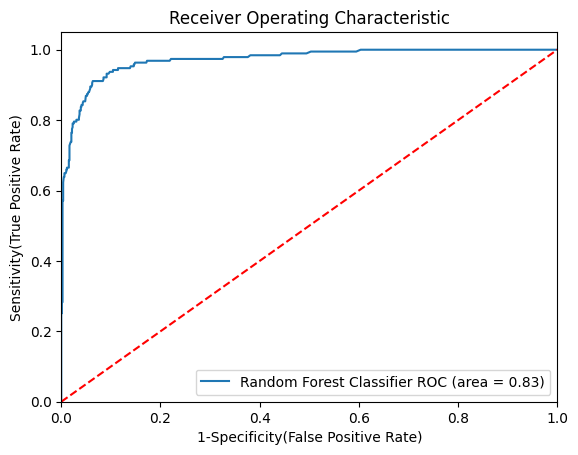

In [57]:
## Plot ROC AUC Curve
plt.figure()

# Add the models to the list that you want to view on the ROC plot
auc_models = [
{
    'label': 'Random Forest Classifier',
    'model': RandomForestClassifier(n_estimators=1000,min_samples_split=2,
                                          max_features=7,max_depth=None),
    'auc':  0.8325
},
    
]
# create loop through all model
for algo in auc_models:
    model = algo['model'] # select the model
    model.fit(X_train, y_train) # train the model
# Compute False postive rate, and True positive rate
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
# Calculate Area under the curve to display on the plot
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 